In [15]:
#Task 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from google.colab import files
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

np.random.seed(42)
uploaded = files.upload()
df = pd.read_csv("banknote_authentication.csv",header=None)
df.columns = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]
print("BANKNOTE AUTHENTICATION DATASET")

print("\nFirst Five Rows\n")
print(df.head())

print("\nDataset Shape")
print(df.shape)

rows, columns = df.shape

print("Rows :", rows)
print("Columns :", columns)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nStatistical Summary")
print(df.describe())

print("\nData Types")
print(df.dtypes)

Saving banknote_authentication.csv to banknote_authentication (2).csv
BANKNOTE AUTHENTICATION DATASET

First Five Rows

   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Dataset Shape
(1372, 5)
Rows : 1372
Columns : 5

Column Names
Index(['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class'], dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 K

<Figure size 1200x800 with 0 Axes>

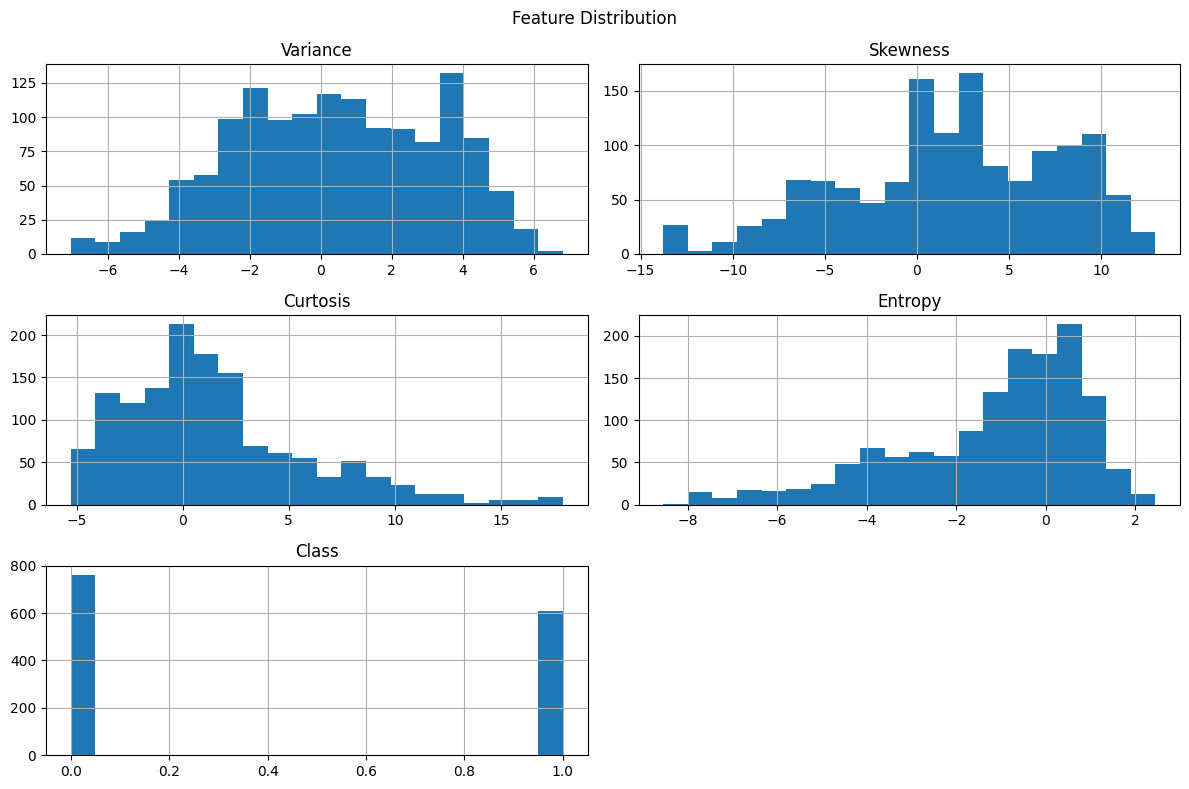

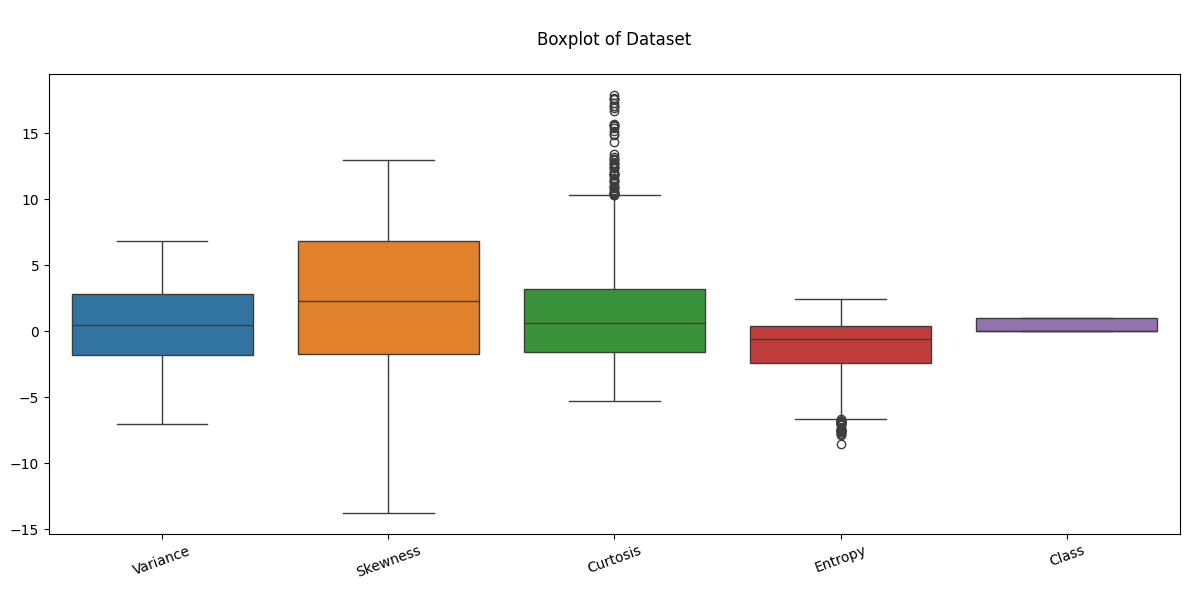


Correlation Matrix

          Variance  Skewness  Curtosis   Entropy     Class
Variance  1.000000  0.264026 -0.380850  0.276817 -0.724843
Skewness  0.264026  1.000000 -0.786895 -0.526321 -0.444688
Curtosis -0.380850 -0.786895  1.000000  0.318841  0.155883
Entropy   0.276817 -0.526321  0.318841  1.000000 -0.023424
Class    -0.724843 -0.444688  0.155883 -0.023424  1.000000


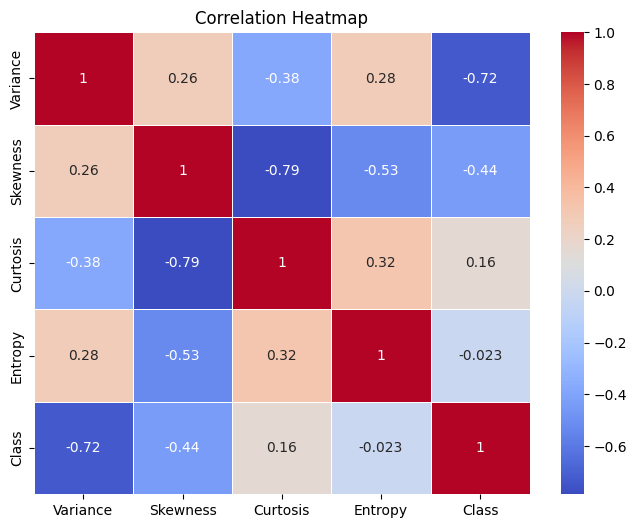

<Figure size 800x600 with 0 Axes>

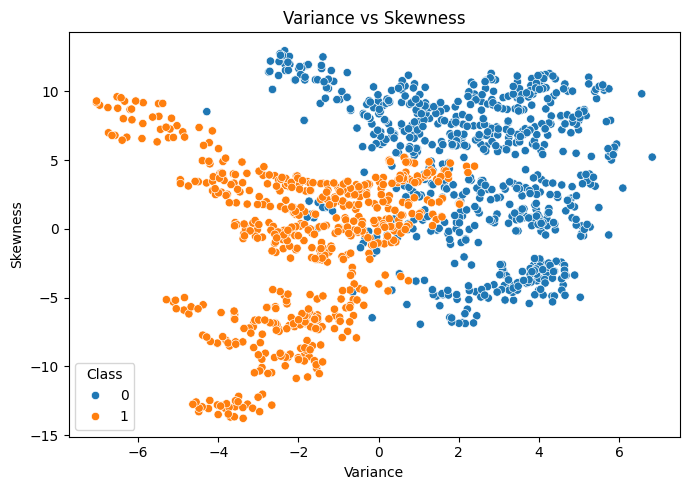

In [16]:
# Task 2
plt.figure(figsize=(12,8))
df.hist(figsize=(12,8), bins=20)
plt.suptitle("Feature Distribution")
plt.tight_layout()
plt.savefig("Feature_Distribution.eps", format="eps", bbox_inches="tight")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("\nBoxplot of Dataset\n")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("Boxplot.eps", format="eps", bbox_inches="tight")
plt.show()

correlation = df.corr()
print("\nCorrelation Matrix\n")
print(correlation)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.savefig("Correlation_Heatmap.eps", format="eps", bbox_inches="tight")
plt.show()
plt.figure(figsize=(8,6))

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class"
)

plt.title("Variance vs Skewness")
plt.legend(title="Class")
plt.tight_layout()

plt.savefig("Scatter_Plot.eps", format="eps", dpi=600)
plt.show()




In [17]:
#Task 3

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print("\nFeature Matrix Shape")
print(X.shape)

print("\nTarget Shape")
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFeatures after Normalization")
print(X_train[:5])

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))

print("\nData Preprocessing Completed")


Feature Matrix Shape
(1372, 4)

Target Shape
(1372,)

Features after Normalization
[[0.40770468 0.98319906 0.25669744 0.0933179 ]
 [0.70790876 0.77197125 0.18087258 0.80514028]
 [0.19855916 0.22113625 0.73742814 0.6209118 ]
 [0.8942662  0.65590259 0.15209132 0.89883014]
 [0.56245159 0.62872549 0.35265884 0.79173938]]

Training Samples : 1097
Testing Samples : 275

Data Preprocessing Completed


In [18]:
# Task 4

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.errors = []
        self.weight_history = []
        self.bias_history = []

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

        for epoch in range(self.epochs):
            error_count = 0

            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = self.activation(linear_output)
                update = self.learning_rate * (y[i] - prediction)
                self.weights += update * X[i]
                self.bias += update

                if update != 0:
                    error_count += 1

            self.errors.append(error_count)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)
            print(f"\nEpoch {epoch+1}")
            print(f"Misclassified Samples : {error_count}")
            print("Updated Weights :", self.weights)
            print("Updated Bias :", self.bias)

            if error_count == 0:
                print("\nTraining Converged.")
                break

In [19]:
# Task 5

learning_rate = 0.01
epochs = 100

model = Perceptron(
    learning_rate=learning_rate,
    epochs=epochs
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



Epoch 1
Misclassified Samples : 177
Updated Weights : [-0.07789202 -0.04682787 -0.05437597  0.02075007]
Updated Bias : 0.07

Epoch 2
Misclassified Samples : 97
Updated Weights : [-0.08742182 -0.06768836 -0.07725424  0.01501699]
Updated Bias : 0.09999999999999999

Epoch 3
Misclassified Samples : 53
Updated Weights : [-0.09852326 -0.0741578  -0.08260144  0.01472139]
Updated Bias : 0.10999999999999999

Epoch 4
Misclassified Samples : 51
Updated Weights : [-0.10656597 -0.07855913 -0.0898593   0.01534688]
Updated Bias : 0.11999999999999998

Epoch 5
Misclassified Samples : 45
Updated Weights : [-0.10587377 -0.08597543 -0.09952408  0.00957725]
Updated Bias : 0.12999999999999998

Epoch 6
Misclassified Samples : 47
Updated Weights : [-0.10917647 -0.08894271 -0.10761958  0.00543993]
Updated Bias : 0.13999999999999999

Epoch 7
Misclassified Samples : 38
Updated Weights : [-0.1169774  -0.09791148 -0.109276    0.01261506]
Updated Bias : 0.13999999999999999

Epoch 8
Misclassified Samples : 37
Updat

MODEL PERFORMANCE
Accuracy  : 0.9927
Precision : 1.0000
Recall    : 0.9843
F1 Score  : 0.9921

Final Weights
[-0.24764923 -0.22840107 -0.25342912  0.00739736]

Final Bias
0.3100000000000001


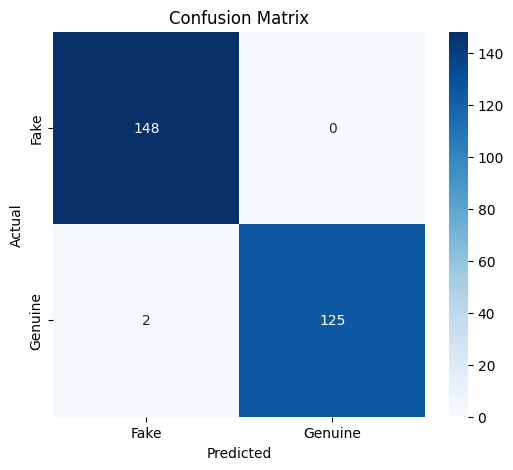

In [20]:
# Task 6
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nFinal Weights")
print(model.weights)

print("\nFinal Bias")
print(model.bias)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake","Genuine"],
    yticklabels=["Fake","Genuine"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("Confusion_Matrix.eps", format="eps", bbox_inches="tight")
plt.show()


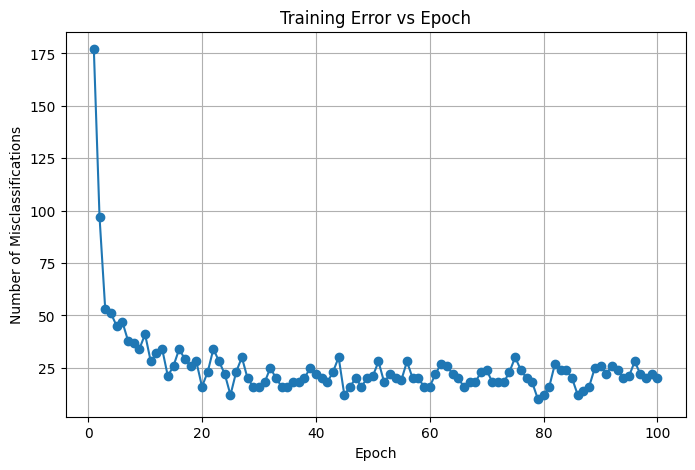

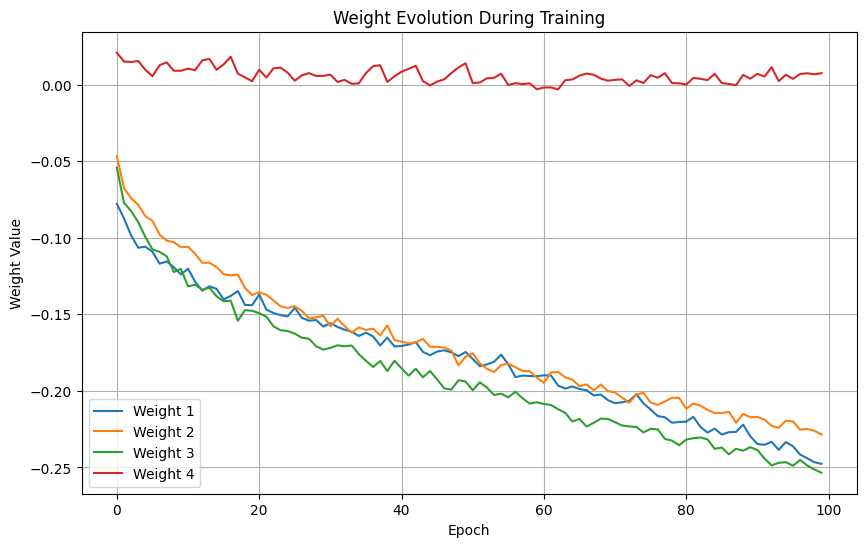

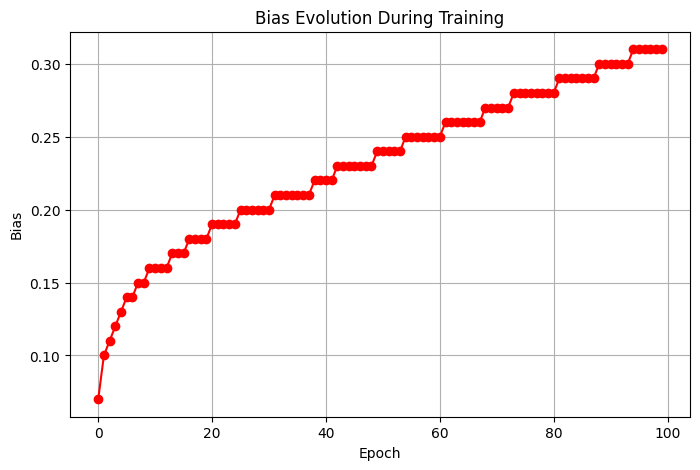


Epoch 1
Misclassified Samples : 225
Updated Weights : [-0.00860556 -0.00242535 -0.00604665  0.00262101]
Updated Bias : 0.007

Epoch 2
Misclassified Samples : 78
Updated Weights : [-0.0090608  -0.00610427 -0.00751635  0.00217034]
Updated Bias : 0.009000000000000001

Epoch 3
Misclassified Samples : 68
Updated Weights : [-0.00934905 -0.00739333 -0.00912592  0.00184584]
Updated Bias : 0.011000000000000003

Epoch 4
Misclassified Samples : 57
Updated Weights : [-0.01029529 -0.00859064 -0.00919746  0.00184235]
Updated Bias : 0.012000000000000004

Epoch 5
Misclassified Samples : 43
Updated Weights : [-0.01032154 -0.00797772 -0.0108128   0.00125089]
Updated Bias : 0.013000000000000005

Epoch 6
Misclassified Samples : 46
Updated Weights : [-0.01108298 -0.00948164 -0.01077237  0.0015927 ]
Updated Bias : 0.013000000000000005

Epoch 7
Misclassified Samples : 37
Updated Weights : [-0.01097009 -0.00943783 -0.01164071  0.00130236]
Updated Bias : 0.014000000000000005

Epoch 8
Misclassified Samples : 4

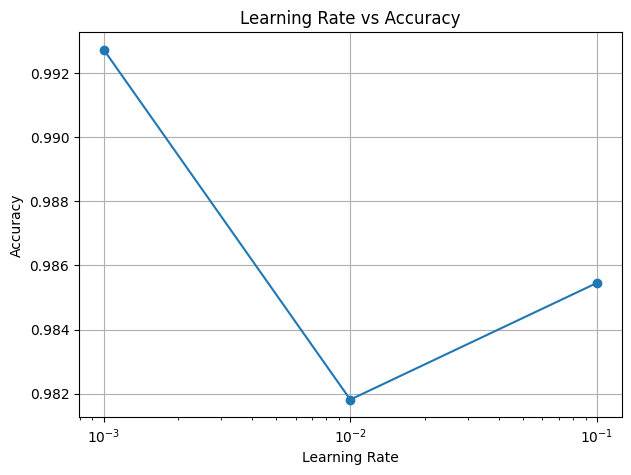

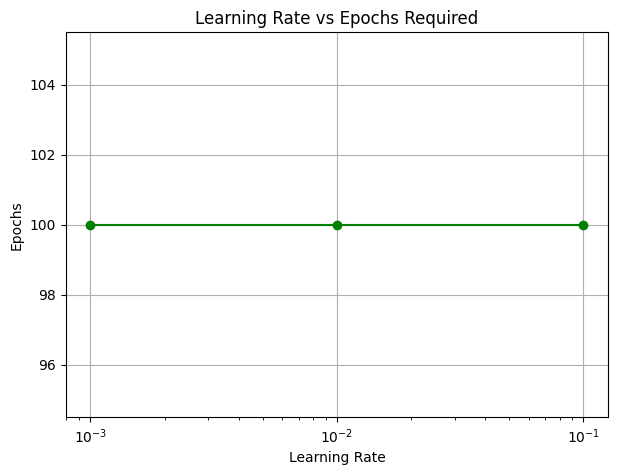

In [21]:
# Task 7
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(model.errors)+1),
    model.errors,
    marker='o'
)
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.title("Training Error vs Epoch")
plt.grid(True)
plt.savefig("Training_Error_vs_Epoch.eps", format="eps", bbox_inches="tight")
plt.show()

weight_history = np.array(model.weight_history)
plt.figure(figsize=(10,6))

for i in range(weight_history.shape[1]):
    plt.plot(
        weight_history[:, i],
        label=f"Weight {i+1}"
    )
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution During Training")
plt.legend()
plt.grid(True)
plt.savefig("Weight_Evolution.eps", format="eps", bbox_inches="tight")
plt.show()


plt.figure(figsize=(8,5))
plt.plot(
    model.bias_history,
    color='red',
    marker='o'
)
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias Evolution During Training")
plt.grid(True)
plt.savefig("Bias_Evolution.eps", format="eps", bbox_inches="tight")
plt.show()

learning_rates = [0.001, 0.01, 0.1]
accuracies = []
epochs_taken = []

for lr in learning_rates:
    temp_model = Perceptron(
        learning_rate=lr,
        epochs=100
    )
    temp_model.fit(X_train, y_train)
    prediction = temp_model.predict(X_test)
    acc = accuracy_score(y_test, prediction)
    accuracies.append(acc)
    epochs_taken.append(len(temp_model.errors))
print("\nLearning Rate Comparison")

for lr, acc, ep in zip(learning_rates, accuracies, epochs_taken):
    print("Learning Rate :", lr)
    print("Accuracy      :", round(acc,4))
    print("Epochs Used   :", ep)

plt.figure(figsize=(7,5))

plt.plot(
    learning_rates,
    accuracies,
    marker='o'
)

plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy")
plt.grid(True)
plt.savefig("Learning_Rate_vs_Accuracy.eps", format="eps", bbox_inches="tight")
plt.show()
plt.figure(figsize=(7,5))

plt.plot(
    learning_rates,
    epochs_taken,
    marker='o',
    color='green'
)
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Epochs")
plt.title("Learning Rate vs Epochs Required")
plt.grid(True)
plt.savefig("Learning_Rate_vs_Epochs.eps", format="eps", bbox_inches="tight")
plt.show()